Libraries loaded successfully
Features : 21
Target   : dsr  (mean=0.3024, std=0.8008)
Feature list:
['sex', 'education', 'marital_status', 'region', 'employment_status', 'employment_type', 'h19_pers_income1', 'h19_pers_income2', 'h19_pers_income4', 'h19_cin', 'h19_din', 'debt_financial', 'debt_private', 'debt_card', 'debt_lease', 'debt_credit', 'debt_other', 'housing_debt_balance', 'housing_tenure', 'age', 'total_debt']
Imputation complete
Missing after imputation : 0
Train : (1532, 21)  |  DSR mean (train) : 0.2941
Test  : (384, 21)   |  DSR mean (test)  : 0.3353
=== LightGBM ===
  RMSE : 0.5596
  MAE  : 0.2515
  R²   : 0.5968
=== XGBoost ===
  RMSE : 0.5805
  MAE  : 0.2482
  R²   : 0.5662
=== Ensemble (LightGBM + XGBoost avg) ===
  RMSE : 0.5604
  MAE  : 0.2455
  R²   : 0.5957
   Model   RMSE    MAE     R²
LightGBM 0.5596 0.2515 0.5968
 XGBoost 0.5805 0.2482 0.5662
Ensemble 0.5604 0.2455 0.5957
Saved -> outputs/model_performance_regression.csv


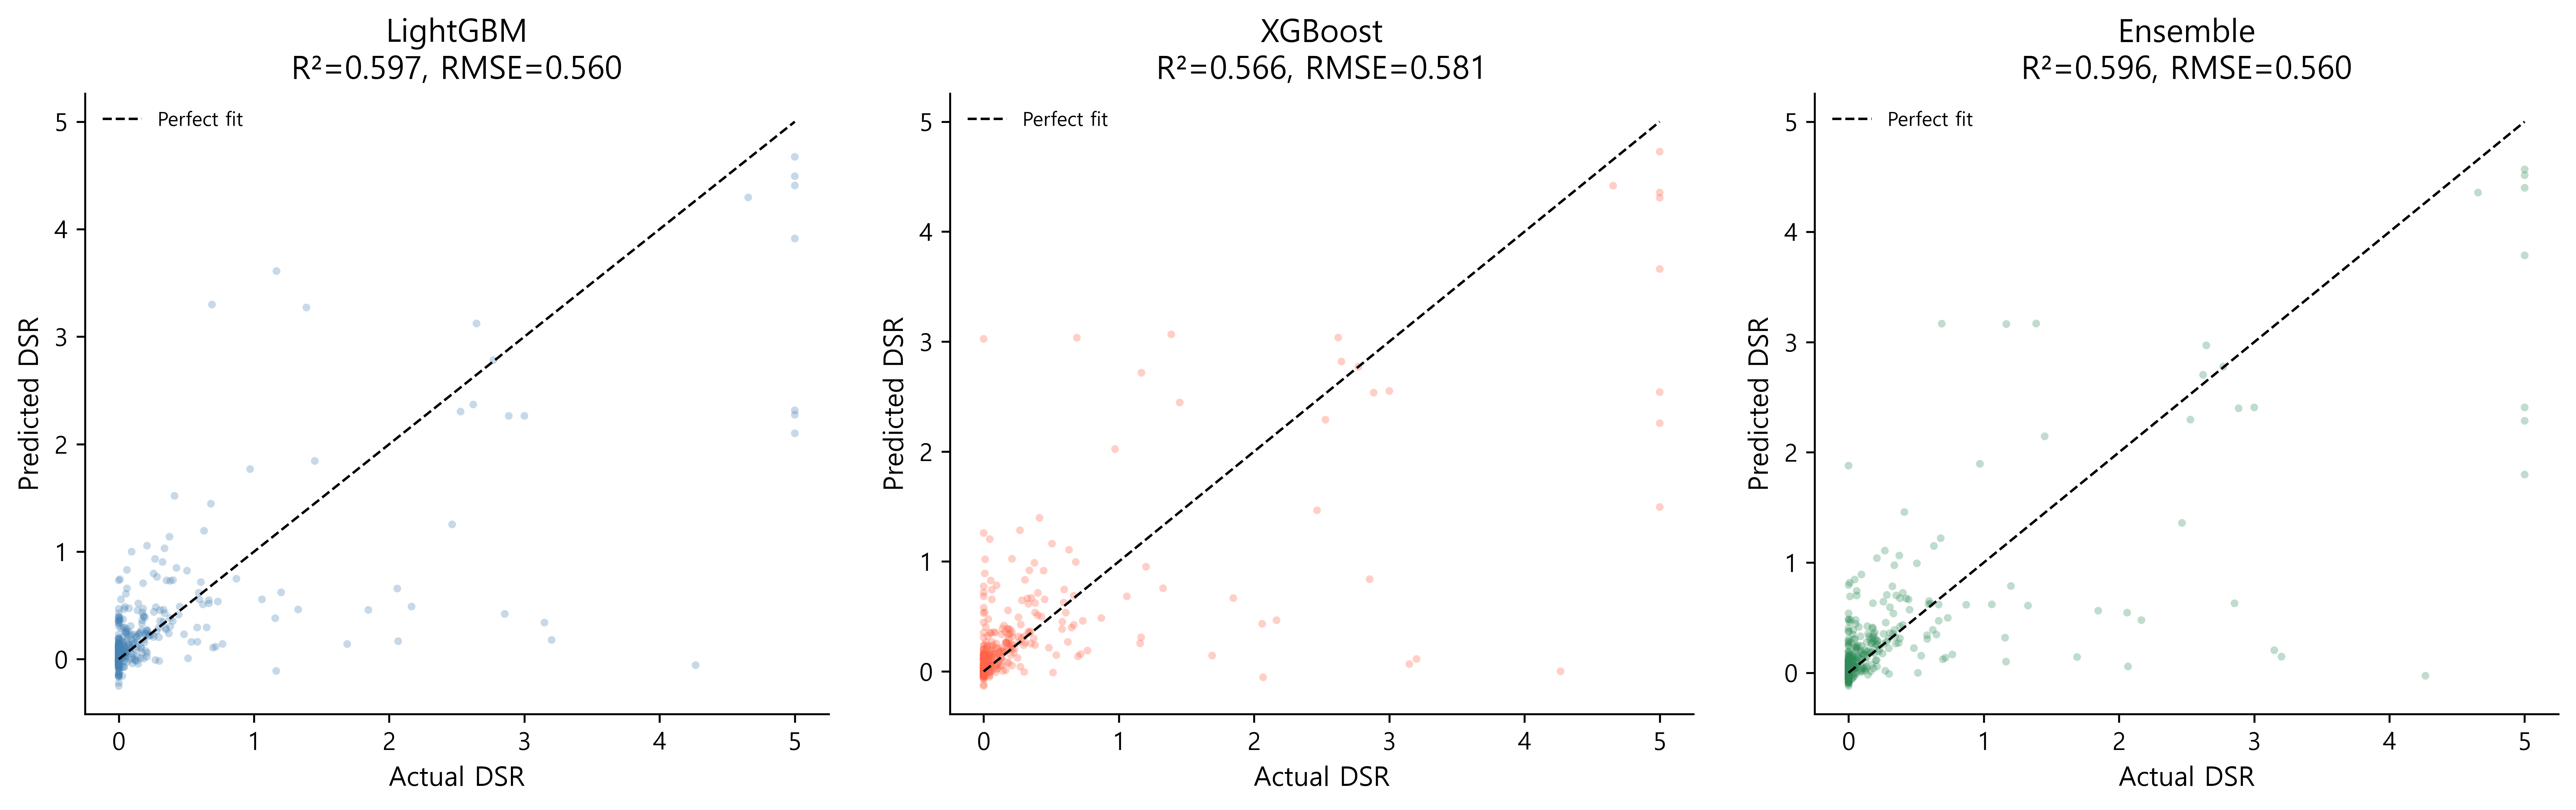

Saved -> outputs/08_predicted_vs_actual.png


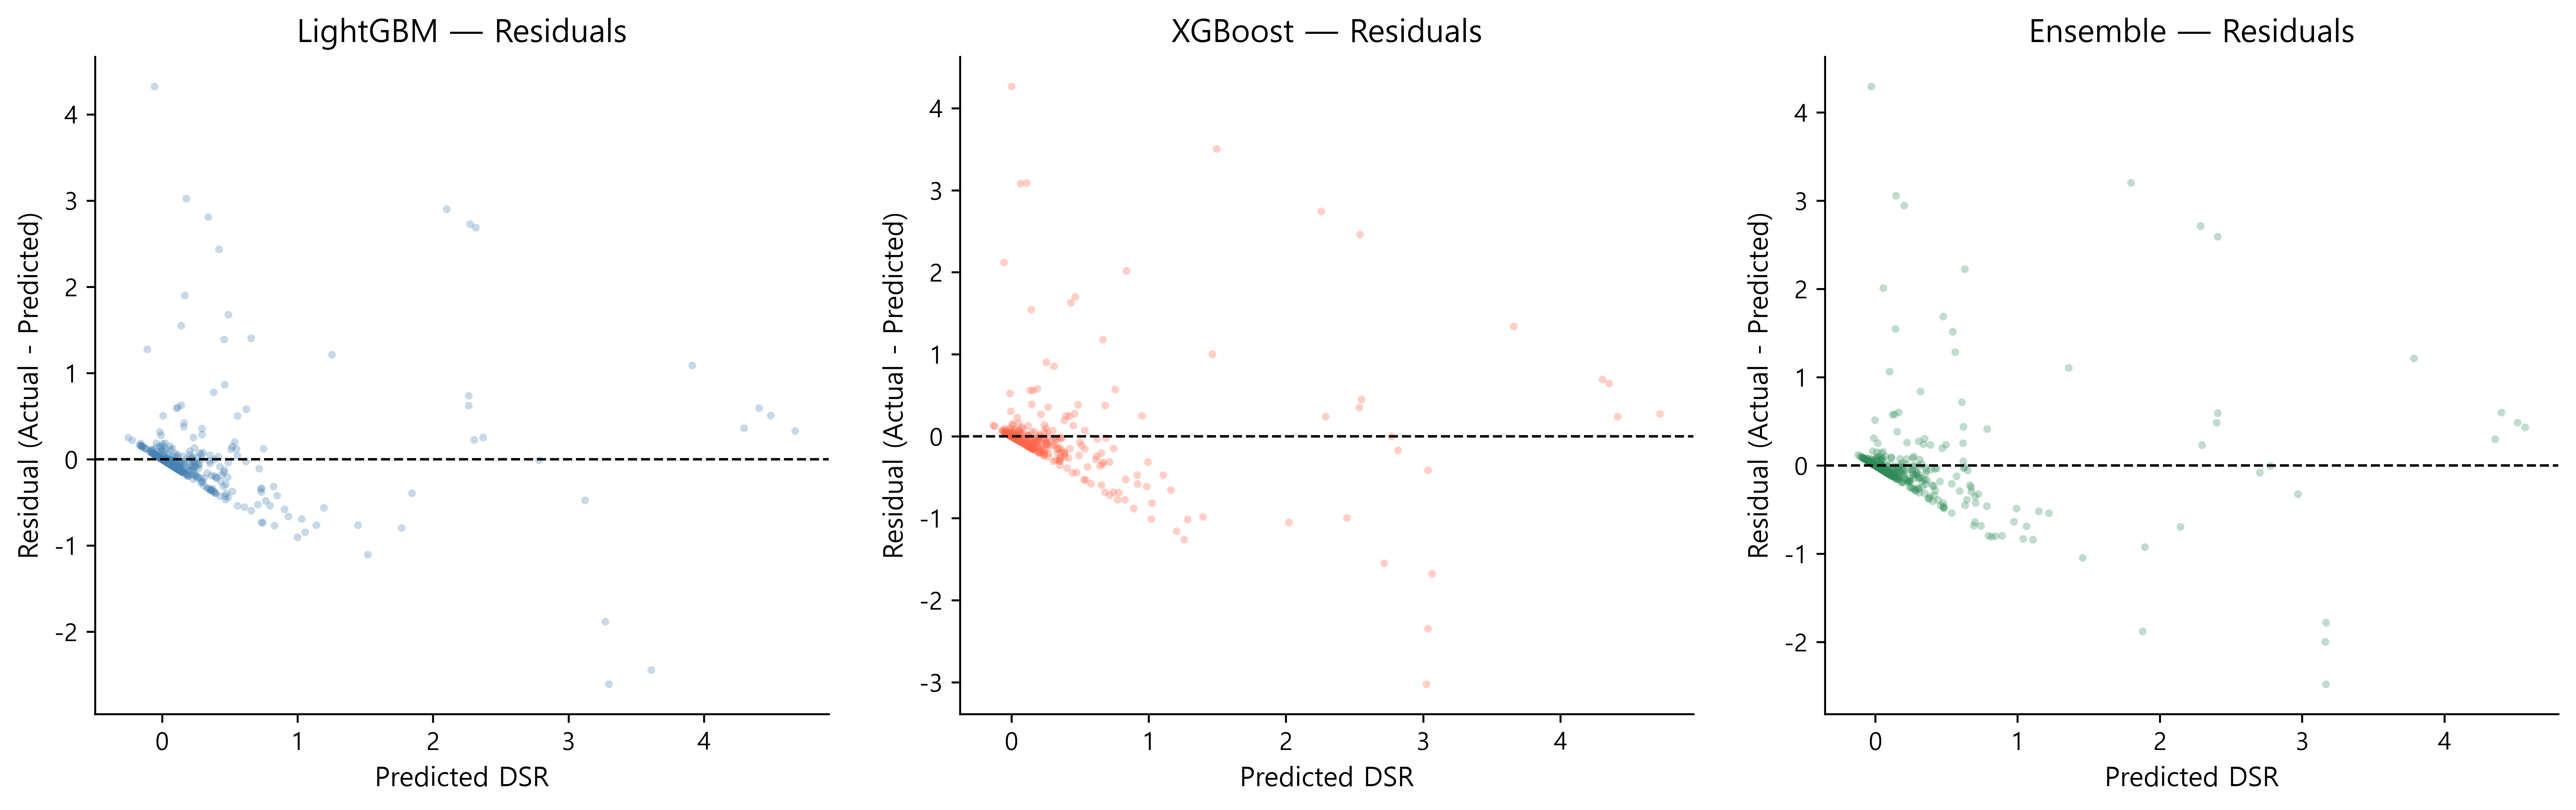

Saved -> outputs/09_residual_plots.png
=== 5-Fold Cross-Validation (neg_root_mean_squared_error) ===
LightGBM CV RMSE: 0.5498 +/- 0.0182
XGBoost CV RMSE: 0.5372 +/- 0.0436

=== 5-Fold Cross-Validation (r2) ===
LightGBM CV R²  : 0.5194 +/- 0.0525
XGBoost CV R²  : 0.5439 +/- 0.0495
Models saved  -> outputs/model_lgbm_reg.pkl, model_xgb_reg.pkl
Test data saved -> data/X_test_reg.csv, y_test_reg.csv
Ensemble preds  -> data/y_pred_ens_reg.csv


In [1]:
# ─────────────────────────────────────────────
# Cell 1 | Import libraries
# ─────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
import warnings
import joblib

from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.impute import SimpleImputer
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor
from scipy import stats

warnings.filterwarnings('ignore')
matplotlib.rcParams['font.family'] = 'Malgun Gothic'
matplotlib.rcParams['axes.unicode_minus'] = False
matplotlib.rcParams['figure.dpi'] = 600
matplotlib.rcParams['savefig.dpi'] = 600
matplotlib.rcParams['font.size'] = 11
matplotlib.rcParams['axes.titlesize'] = 13
matplotlib.rcParams['axes.labelsize'] = 11
matplotlib.rcParams['xtick.labelsize'] = 10
matplotlib.rcParams['ytick.labelsize'] = 10
matplotlib.rcParams['lines.linewidth'] = 1.5
matplotlib.rcParams['axes.linewidth'] = 0.8

SAVE_KW = dict(dpi=600, bbox_inches='tight', format='png')

print("Libraries loaded successfully")


# ─────────────────────────────────────────────
# Cell 2 | Load data & define features
# Target variable changed from debt_crisis (binary)
# to dsr (continuous regression target)
# ─────────────────────────────────────────────
df = pd.read_csv("../data/youth_debt_preprocessed_regression.csv")

# Exclude DSR construction variables to prevent target leakage
# Also exclude near-zero-variance income columns (>95% missing)
DROP_COLS = [
    'h19_pid', 'p19_wgc', 'h19_g4',
    'h19_pers_income3', 'h19_pers_income5',
    'h1906_10', 'dsr_raw', 'dsr_bin',
    'annual_debt_service', 'annual_interest', 'annual_repayment',
    'total_income', 'h1909_aq7', 'h1909_aq8', 'h1906_aq2',
    'debt_crisis',  # classification label excluded from regression
]

FEATURE_COLS = [c for c in df.columns if c not in DROP_COLS + ['dsr']]

X = df[FEATURE_COLS].copy()
y = df['dsr'].copy()   # continuous regression target

print(f"Features : {len(FEATURE_COLS)}")
print(f"Target   : dsr  (mean={y.mean():.4f}, std={y.std():.4f})")
print(f"Feature list:\n{FEATURE_COLS}")


# ─────────────────────────────────────────────
# Cell 3 | Impute missing values
# Median imputation consistent with classification paper
# ─────────────────────────────────────────────
imputer = SimpleImputer(strategy='median')
X_imp   = pd.DataFrame(imputer.fit_transform(X), columns=FEATURE_COLS)

print("Imputation complete")
print(f"Missing after imputation : {X_imp.isnull().sum().sum()}")


# ─────────────────────────────────────────────
# Cell 4 | Train / test split
# Stratification not applicable for regression;
# random split with fixed seed for reproducibility
# ─────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X_imp, y, test_size=0.2, random_state=42
)

print(f"Train : {X_train.shape}  |  DSR mean (train) : {y_train.mean():.4f}")
print(f"Test  : {X_test.shape}   |  DSR mean (test)  : {y_test.mean():.4f}")


# ─────────────────────────────────────────────
# Cell 5 | Helper function: regression metrics
# ─────────────────────────────────────────────
def reg_metrics(y_true, y_pred, label=''):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    print(f"=== {label} ===")
    print(f"  RMSE : {rmse:.4f}")
    print(f"  MAE  : {mae:.4f}")
    print(f"  R²   : {r2:.4f}")
    return {'rmse': rmse, 'mae': mae, 'r2': r2}


# ─────────────────────────────────────────────
# Cell 6 | Train LightGBM Regressor
# SMOTE removed: not applicable for regression
# ─────────────────────────────────────────────
lgbm = LGBMRegressor(
    n_estimators=500, learning_rate=0.05, max_depth=6,
    num_leaves=31, subsample=0.8, colsample_bytree=0.8,
    min_child_samples=10,
    random_state=42, verbose=-1,
)
lgbm.fit(X_train, y_train,
         eval_set=[(X_test, y_test)],
         callbacks=[])

y_pred_lgbm = lgbm.predict(X_test)
metrics_lgbm = reg_metrics(y_test, y_pred_lgbm, 'LightGBM')


# ─────────────────────────────────────────────
# Cell 7 | Train XGBoost Regressor
# ─────────────────────────────────────────────
xgb = XGBRegressor(
    n_estimators=500, learning_rate=0.05, max_depth=6,
    subsample=0.8, colsample_bytree=0.8,
    random_state=42, eval_metric='rmse', verbosity=0,
)
xgb.fit(X_train, y_train,
        eval_set=[(X_test, y_test)],
        verbose=False)

y_pred_xgb = xgb.predict(X_test)
metrics_xgb = reg_metrics(y_test, y_pred_xgb, 'XGBoost')


# ─────────────────────────────────────────────
# Cell 8 | Ensemble (soft averaging of predictions)
# ─────────────────────────────────────────────
y_pred_ens = (y_pred_lgbm + y_pred_xgb) / 2
metrics_ens = reg_metrics(y_test, y_pred_ens, 'Ensemble (LightGBM + XGBoost avg)')


# ─────────────────────────────────────────────
# Cell 9 | Performance summary table
# ─────────────────────────────────────────────
perf_df = pd.DataFrame({
    'Model': ['LightGBM', 'XGBoost', 'Ensemble'],
    'RMSE' : [metrics_lgbm['rmse'], metrics_xgb['rmse'], metrics_ens['rmse']],
    'MAE'  : [metrics_lgbm['mae'],  metrics_xgb['mae'],  metrics_ens['mae']],
    'R²'   : [metrics_lgbm['r2'],   metrics_xgb['r2'],   metrics_ens['r2']],
}).round(4)

print(perf_df.to_string(index=False))
perf_df.to_csv('../outputs/model_performance_regression.csv',
               index=False, encoding='utf-8-sig')
print("Saved -> outputs/model_performance_regression.csv")


# ─────────────────────────────────────────────
# Cell 10 | Predicted vs Actual plots
# ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

model_preds = {
    'LightGBM': y_pred_lgbm,
    'XGBoost' : y_pred_xgb,
    'Ensemble': y_pred_ens,
}
colors = ['steelblue', 'tomato', 'seagreen']

for ax, (name, pred), color in zip(axes, model_preds.items(), colors):
    ax.scatter(y_test, pred, alpha=0.3, s=10, color=color, edgecolor='none')
    lims = [0, max(y_test.max(), pred.max())]
    ax.plot(lims, lims, 'k--', lw=1.0, label='Perfect fit')
    r2  = r2_score(y_test, pred)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    ax.set_title(f'{name}\nR²={r2:.3f}, RMSE={rmse:.3f}')
    ax.set_xlabel('Actual DSR')
    ax.set_ylabel('Predicted DSR')
    ax.legend(frameon=False, fontsize=8)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout(pad=2.0)
plt.savefig('../outputs/08_predicted_vs_actual.png', **SAVE_KW)
plt.show()
print("Saved -> outputs/08_predicted_vs_actual.png")


# ─────────────────────────────────────────────
# Cell 11 | Residual plots
# ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, (name, pred), color in zip(axes, model_preds.items(), colors):
    residuals = y_test.values - pred
    ax.scatter(pred, residuals, alpha=0.3, s=10, color=color, edgecolor='none')
    ax.axhline(0, color='black', linestyle='--', lw=1.0)
    ax.set_title(f'{name} — Residuals')
    ax.set_xlabel('Predicted DSR')
    ax.set_ylabel('Residual (Actual - Predicted)')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout(pad=2.0)
plt.savefig('../outputs/09_residual_plots.png', **SAVE_KW)
plt.show()
print("Saved -> outputs/09_residual_plots.png")


# ─────────────────────────────────────────────
# Cell 12 | Cross-validation (5-fold)
# KFold used instead of StratifiedKFold
# (stratification not applicable for continuous target)
# ─────────────────────────────────────────────
cv = KFold(n_splits=5, shuffle=True, random_state=42)

print("=== 5-Fold Cross-Validation (neg_root_mean_squared_error) ===")
for name, model in [('LightGBM', lgbm), ('XGBoost', xgb)]:
    scores = cross_val_score(model, X_imp, y, cv=cv,
                             scoring='neg_root_mean_squared_error')
    rmse_scores = -scores
    print(f"{name} CV RMSE: {rmse_scores.mean():.4f} +/- {rmse_scores.std():.4f}")

print("\n=== 5-Fold Cross-Validation (r2) ===")
for name, model in [('LightGBM', lgbm), ('XGBoost', xgb)]:
    scores = cross_val_score(model, X_imp, y, cv=cv, scoring='r2')
    print(f"{name} CV R²  : {scores.mean():.4f} +/- {scores.std():.4f}")


# ─────────────────────────────────────────────
# Cell 13 | Save models & data
# ─────────────────────────────────────────────
joblib.dump(lgbm,    '../outputs/model_lgbm_reg.pkl')
joblib.dump(xgb,     '../outputs/model_xgb_reg.pkl')
joblib.dump(imputer, '../outputs/imputer_reg.pkl')

X_test.to_csv('../data/X_test_reg.csv', index=False)
y_test.to_csv('../data/y_test_reg.csv', index=False)
X_train.to_csv('../data/X_train_reg.csv', index=False)
y_train.to_csv('../data/y_train_reg.csv', index=False)
pd.Series(FEATURE_COLS).to_csv('../data/feature_cols_reg.csv', index=False)

# Save ensemble predictions for downstream XAI notebooks
pd.Series(y_pred_ens, name='y_pred_ens').to_csv(
    '../data/y_pred_ens_reg.csv', index=False)

print("Models saved  -> outputs/model_lgbm_reg.pkl, model_xgb_reg.pkl")
print("Test data saved -> data/X_test_reg.csv, y_test_reg.csv")
print("Ensemble preds  -> data/y_pred_ens_reg.csv")